# Optimization in Machine Learning

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [K Fold](#kfold)
3. [GridsearchCV](#grid)
5. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction </i></b>
    <a id="introduction"></a></div>

In machine learning, optimization refers to the process of improving a model’s performance by finding the best possible configuration of its parameters and hyperparameters. The goal is to build a model that not only fits the training data well but also generalizes effectively to unseen data.

In [470]:
from sklearn.datasets import load_iris
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC as svm

We will use again the iris dataset.

In [471]:
iris = load_iris()
X = iris.data[:,:2]
y = (iris.target == 0).astype(int) 

<div class="alert alert-warning">
    <b> II. <i>K-Folding </i></b>
    <a id="kfold"></a></div>

K-Fold Cross Validation is a model evaluation technique that helps obtain a more robust measure of the performance of a classification model, especially when the available dataset is limited. This technique splits the dataset into k subsets or "folds," and uses each subset multiple times to train and validate the model. This way, a more reliable estimate of the model’s ability to generalize to new data can be obtained.

A model can perform well on training data but poorly on new data (overfitting). To avoid this, we use K-Fold Cross Validation.

To perform this task, we again use scikit-learn — specifically, the KFold function. This function has the following parameters:

- `n_splits`: Number of splits to make.

- `shuffle`: Boolean indicating whether the data should be shuffled before splitting.

- `random_state`: Random seed.

It returns the different train and test splits, ensuring that the training set and test set sizes follow the specified distribution.

We will use the function ```KFold`` to do cross validation. This function takes these parameters: 
- ``n_splits``: how many folds you want.
- ``shuffle``: Before splitting the data, it is shuffled randomly. 
- ``random_state``: To control randomness. 

We can define a function that performs: 
- Kfolding 
- Training and Testing spliting
- Train a model 
- Test it and evaluate performance. 

Returning the average performance, the results of each fold and the best model.

In [472]:
def cross_validate(model, X, y, k=5):
     # 1. We create a K-Fold object that will split the data into 5 parts, 
     # shuffle the dataset before splitting and use fixed seed
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Variables to store results
    scores = [] 
    best_score = -1 
    best_model = None

    # Kfold returns the indices of the rows used for training and testing. 
    for train_index, test_index in kf.split(X):
        #split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # train model
        model.fit(X_train, y_train)

        # make prediction
        y_pred = model.predict(X_test)

        # evaluate performance
        score = accuracy_score(y_test, y_pred)
        scores.append(score)

        #store result
        if score > best_score:
            best_score = score
            best_model = model

    return np.mean(scores), scores, best_model #<- We return the mean accuracy, all fold accuracy and best model

Let's see how this works. We create a Logistic Regression model.

In [473]:
model = LogisticRegression()

And compute cross validation:

In [474]:
mean_score, scores, best_model = cross_validate(model, X, y, 5)
print(f"Mean score:{mean_score}")
print(f"Scores: {scores}")

Mean score:1.0
Scores: [1.0, 1.0, 1.0, 1.0, 1.0]


What can we do with the best_model variable? 

We can print the hyperparameters with we trained the model. 

In [475]:
print(best_model.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


<div class="alert alert-warning">
    <b> III. <i>Gridsearch </i></b>
    <a id="grid"></a></div>

In the training of machine learning models, a hyperparameter is any parameter that is not directly learned during the training process but must be defined before training begins. These parameters are configurations that influence the behavior of the model, as well as its ability to learn and generalize on new datasets.

Unlike parameters that are determined during the training of the model (such as weights in a neural network), hyperparameters must be set beforehand, typically based on the designer's experience, trial and error, or through search techniques.

GridSearchCV automates the search for the best combination of hyperparameters by:

- Trying all possible combinations from a predefined grid
- Evaluating each using cross-validation
- Selecting the configuration with the best average performance

This ensures the model is not only trained, but also systematically optimized.

In order to use GridSearchCV, we need to create a dictionary of all the parameters we want to try our model:

In [476]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

Then, we can create an object ``GridSearchCV`` with the following parameters: 
- ``estimator``:The model you want to optimize.
- ``param_grid``: Dictionary of parameters to try.
- ``cv``: Use 5-fold cross validation.
- ``scoring``: Metric used to compare models. We can indicate accuracy, precision, recall,F1.
- ``verbose``: Prints progress while running if set to 1.

In [477]:
model = svm()
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

Once we have the object created, we call ``fit`` to mtrain the grid search:

In [478]:
grid.fit(X, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=1)

To see the results we can call to ``best_params`` and ``best_score``:

In [479]:
print("Best parameters:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best accuracy: 1.0


We can obtain the best model calling ``best_estimator_``

In [480]:
best_model = grid.best_estimator_

Then, we can perform predictions and compute more metrics: 

In [481]:
predictions = best_model.predict(X)
print("\nReport:\n", classification_report(y, predictions))


Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



<div class="alert alert-warning">
    <b> IV. <i>Exercise </i></b>
    <a id="Exercise"></a></div>

In this exercise, we will use the fish market dataset. The fish market dataset is a collection of data related to different species of fish and their characteristics.

You can download the dataset here: [Link](https://github.com/bmalcover/AppOC/tree/main/docs/_static/01/Fishers%20maket.csv)

You can find more info of the dataset here: [Link](https://www.kaggle.com/datasets/vipullrathod/fish-market)


In [482]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("Fishers maket.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


After reading the dataset, let's see if there is any NaN value and other statistical information. 

In [483]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


There is no None value or NaN. We decided to classify between ``Perch`` and ``No Perch``. The ``No Perch`` class will contain the ``Bream`` and ``Roach`` classes. 

In [484]:
df = df[df["Species"].isin(["Perch", "Bream", "Roach"])].copy()

Let's create our Input features variable (X) and our target variable (Y). Our target variable will contain 1 if the fish is ``Perch``, if not will have a 0: 

In [485]:
X = df.drop("Species", axis=1)
y = (df["Species"] == "Perch").astype(int)

<div class="alert alert-info">

We decided to use Height and Weight variables as input features. Feel free to use other variable and see what happens!

In [486]:
X_2 = df[["Weight", "Height"]]

<div class="alert alert-info">

__Task 1__

Split the data between train and test split. Use ``X_2`` as input features variable.

If we take a look to our features, we can see that ``weight`` has larger values in comparison with height:

In [488]:
print(X_train)

     Weight   Height
15    600.0  15.4380
21    685.0  15.9936
101   218.0   7.1680
26    720.0  16.3618
127  1000.0  12.4888
..      ...      ...
86    120.0   6.1100
102   300.0   8.3230
41    110.0   6.1677
30    920.0  18.0369
76     70.0   4.5880

[77 rows x 2 columns]


A model like SVM or Logistic Regression will treat large numbers as more important just because they are bigger. We need to scale the data. Without this, the weight will dominate the process. 

We are going to use ``StandardScaler``, which performs the following: 
z=x−μ​/σ

In [489]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

We use ``fit`` to make the scaler learn the training data the mean of each feature and the standard deviation of each feature. 

In [490]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

We then use ``transform`` to transform each value using this: 
x`= x- mean / std

We also transform the test data using the same scaler es the training data. As the test data simulates real-world and unseen data, it must be transformed using the rules learned from training. 

<div class="alert alert-info">

__Task 2__

Create a Logistic Regression or SVM model and create a param grid of the parameters: 

In [ ]:
model =...

In [ ]:
param_grid = {
    
}

<div class="alert alert-info">

__Task 3__

Perform gridsearch and print the best params and best score. Remember to use the variable ``X_train_scaled``. 

In [502]:
# Print best_params
# Print best score

<div class="alert alert-info">

__Task 4__

Evaluate the performance. Remember to use ``X_test_scaled``

In [ ]:
y_pred = ....

In [ ]:
print() # Classification report

              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.80      0.94      0.86        17

    accuracy                           0.85        34
   macro avg       0.86      0.85      0.85        34
weighted avg       0.86      0.85      0.85        34



<Axes: >

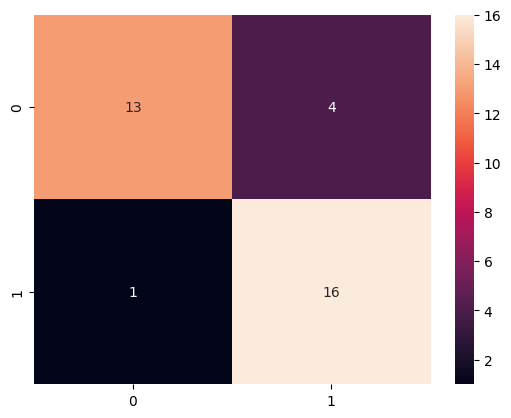

In [ ]:
cm = ... # Confusion Matrix